# GA Optimization Analysis - Seed 43

Comprehensive analysis and visualization of GA optimization results for seed 43.

## 1. Data Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Results data for seed 43
seed = 43
optimal = 45308.0

# Algorithm results
greedy_weight = 27092.0
itai_weight = 20143.0
luby_weight = 25734.0

# Baseline results
baseline = 34897.0
baseline_cascading = 42438.0

# GA results
best_standard = 36706.0
best_cascading = 42421.0
fitness_history_standard = [35947.0, 35958.0, 35958.0, 36040.0, 36574.0, 36706.0, 36706.0, 36706.0, 36706.0, 36706.0]
fitness_history_cascading = [42180.0, 42195.0, 42263.0, 42263.0, 42341.0, 42341.0, 42341.0, 42341.0, 42419.0, 42421.0]

# Gap calculations
greedy_gap = ((optimal - greedy_weight) / (optimal + 1e-10)) * 100
itai_gap = ((optimal - itai_weight) / (optimal + 1e-10)) * 100
luby_gap = ((optimal - luby_weight) / (optimal + 1e-10)) * 100
baseline_gap = ((optimal - baseline) / (optimal + 1e-10)) * 100
ga_gap = ((optimal - best_standard) / (optimal + 1e-10)) * 100
cascading_gap = ((optimal - best_cascading) / (optimal + 1e-10)) * 100

# Improvement
improvement_standard = ((best_standard - baseline) / (baseline + 1e-10)) * 100
improvement_cascading = ((best_cascading - baseline_cascading) / (baseline_cascading + 1e-10)) * 100

print("✓ Data loaded")

✓ Data loaded


## 2. Summary Statistics

In [2]:
print("="*80)
print(f"GA OPTIMIZATION ANALYSIS - SEED {seed}")
print("="*80)
print()
print(f"Optimal (NetworkX):        {optimal:>12.0f}")
print()
print("Individual Algorithms:")
print(f"  Greedy:                 {greedy_weight:>12.0f} (gap: {greedy_gap:>6.2f}%)")
print(f"  Itai-Israeli:           {itai_weight:>12.0f} (gap: {itai_gap:>6.2f}%)")
print(f"  Luby Randomized:        {luby_weight:>12.0f} (gap: {luby_gap:>6.2f}%)")
print()
print("Baselines:")
print(f"  Merged (Standard):      {baseline:>12.0f} (gap: {baseline_gap:>6.2f}%)")
print(f"  Cascading:              {baseline_cascading:>12.0f} (gap: {((optimal - baseline_cascading) / optimal * 100):>6.2f}%)")
print()
print("GA Results:")
print(f"  GA Standard:            {best_standard:>12.0f} (gap: {ga_gap:>6.2f}%, improvement: {improvement_standard:>6.2f}%)")
print(f"  GA Cascading:           {best_cascading:>12.0f} (gap: {cascading_gap:>6.2f}%, improvement: {improvement_cascading:>6.2f}%)")
print()
print("GA Cascading vs GA Standard:")
print(f"  Cascading is {(best_cascading / best_standard - 1) * 100:>6.2f}% better")
print(f"  Difference: {best_cascading - best_standard:>6.0f} weight units")
print("="*80)
print()

GA OPTIMIZATION ANALYSIS - SEED 43

Optimal (NetworkX):               45308

Individual Algorithms:
  Greedy:                        27092 (gap:  40.20%)
  Itai-Israeli:                  20143 (gap:  55.54%)
  Luby Randomized:               25734 (gap:  43.20%)

Baselines:
  Merged (Standard):             34897 (gap:  22.98%)
  Cascading:                     42438 (gap:   6.33%)

GA Results:
  GA Standard:                   36706 (gap:  18.99%, improvement:   5.18%)
  GA Cascading:                  42421 (gap:   6.37%, improvement:  -0.04%)

GA Cascading vs GA Standard:
  Cascading is  15.57% better
  Difference:   5715 weight units



## 3. Generation-by-Generation Analysis

In [3]:
print("="*80)
print("GENERATION-BY-GENERATION ANALYSIS")
print("="*80)
print()
print(f"{'─'*80}")
print(f"SEED {seed}")
print(f"{'─'*80}")
print()

fitness_history = fitness_history_standard
improvements = [0.0] + [fitness_history[i] - fitness_history[i-1] for i in range(1, len(fitness_history))]

print(f"{'Gen':>3} {'Fitness':>12} {'Change':>12} {'% Change':>12} {'Gap to Opt':>12}")
print("-" * 65)

for gen, fitness in enumerate(fitness_history, 1):
    change = improvements[gen-1]
    pct_change = (change / (fitness_history[0] + 1e-10)) * 100
    gap_to_opt = ((optimal - fitness) / (optimal + 1e-10)) * 100
    print(f"{gen:>3} {fitness:>12.0f} {change:>12.0f} {pct_change:>11.2f}% {gap_to_opt:>11.2f}%")

print("-" * 65)
total_improvement = fitness_history[-1] - fitness_history[0]
total_pct = (total_improvement / (fitness_history[0] + 1e-10)) * 100
print(f"Total improvement: {total_improvement:.0f} ({total_pct:+.2f}%)")
print()

GENERATION-BY-GENERATION ANALYSIS

────────────────────────────────────────────────────────────────────────────────
SEED 43
────────────────────────────────────────────────────────────────────────────────

Gen      Fitness       Change     % Change   Gap to Opt
-----------------------------------------------------------------
  1        35947            0        0.00%       20.66%
  2        35958           11        0.03%       20.64%
  3        35958            0        0.00%       20.64%
  4        36040           82        0.23%       20.46%
  5        36574          534        1.49%       19.28%
  6        36706          132        0.37%       18.99%
  7        36706            0        0.00%       18.99%
  8        36706            0        0.00%       18.99%
  9        36706            0        0.00%       18.99%
 10        36706            0        0.00%       18.99%
-----------------------------------------------------------------
Total improvement: 759 (+2.11%)



## 4. Visualization: Baselines Comparison

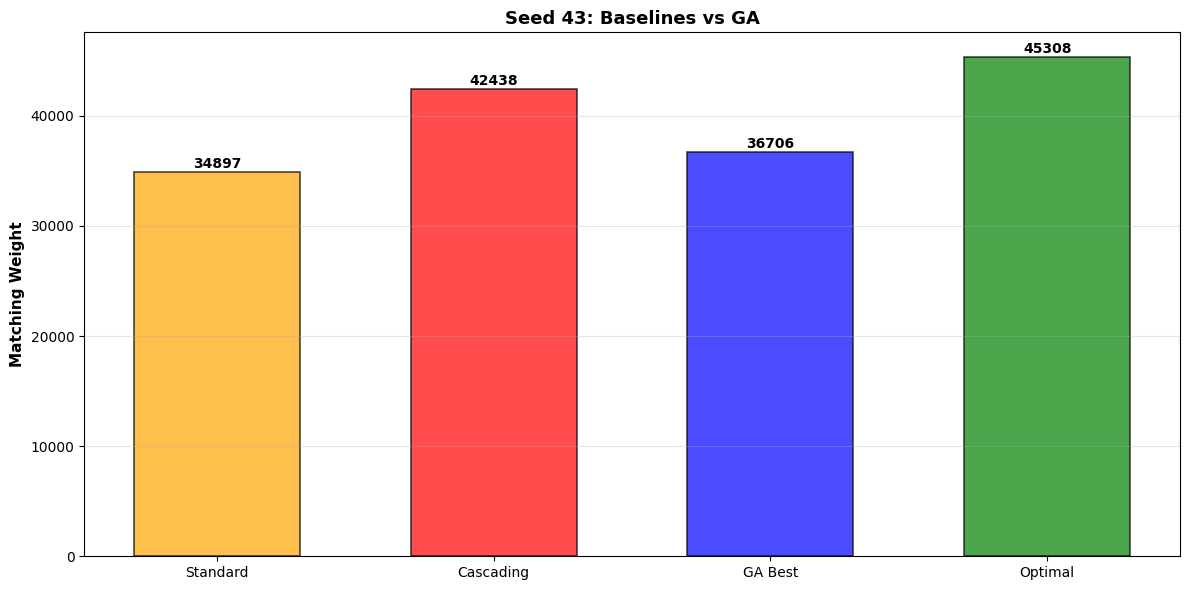

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

values = [baseline, baseline_cascading, best_standard, optimal]
labels = ['Standard', 'Cascading', 'GA Best', 'Optimal']
colors = ['orange', 'red', 'blue', 'green']

bars = ax.bar(labels, values, color=colors, alpha=0.7, width=0.6, edgecolor='black', linewidth=1.2)
ax.set_ylabel('Matching Weight', fontweight='bold', fontsize=11)
ax.set_title(f'Seed {seed}: Baselines vs GA', fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, v) in enumerate(zip(bars, values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 100, f"{v:.0f}", 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 5. Visualization: Quality Metrics

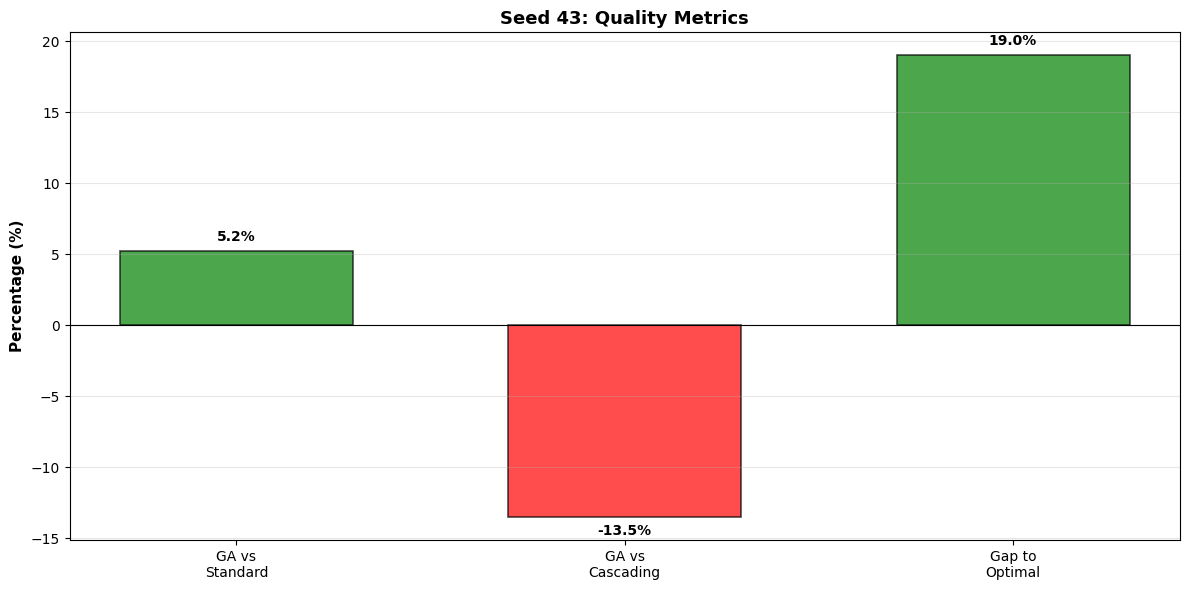

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['GA vs\nStandard', 'GA vs\nCascading', 'Gap to\nOptimal']
improvement_cascading = ((best_standard - baseline_cascading) / baseline_cascading * 100)
values_metrics = [improvement_standard, improvement_cascading, ga_gap]
colors_metrics = ['green' if v > 0 else 'red' for v in values_metrics]

bars = ax.bar(metrics, values_metrics, color=colors_metrics, alpha=0.7, width=0.6, edgecolor='black', linewidth=1.2)
ax.set_ylabel('Percentage (%)', fontweight='bold', fontsize=11)
ax.set_title(f'Seed {seed}: Quality Metrics', fontweight='bold', fontsize=13)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, v) in enumerate(zip(bars, values_metrics)):
    height = bar.get_height()
    offset = 0.5 if v > 0 else -0.5
    ax.text(bar.get_x() + bar.get_width()/2., height + offset, f"{v:.1f}%", 
            ha='center', va='bottom' if v > 0 else 'top', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Visualization: Comprehensive Analysis

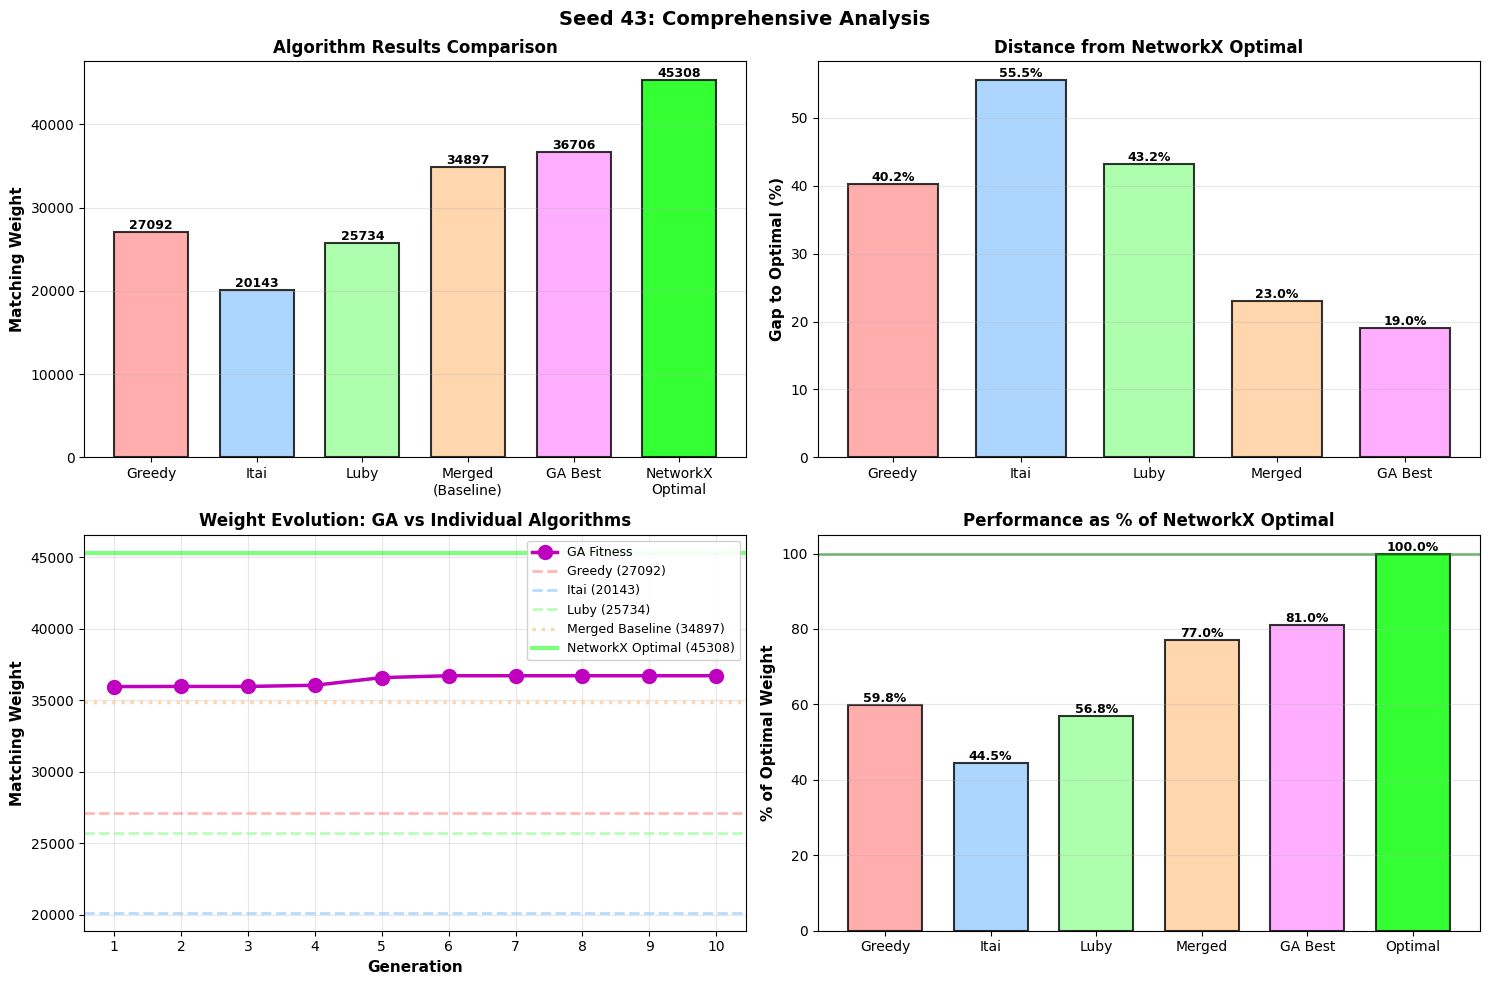

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Seed {seed}: Comprehensive Analysis', fontsize=14, fontweight='bold')

# Plot 1: Individual algorithm weights vs baselines
ax = axes[0, 0]
algorithms = ['Greedy', 'Itai', 'Luby', 'Merged\n(Baseline)', 'GA Best', 'NetworkX\nOptimal']
weights = [greedy_weight, itai_weight, luby_weight, baseline, best_standard, optimal]
colors_alg = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF', '#00FF00']

bars = ax.bar(algorithms, weights, color=colors_alg, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Matching Weight', fontweight='bold', fontsize=11)
ax.set_title('Algorithm Results Comparison', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, weight) in enumerate(zip(bars, weights)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{weight:.0f}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 2: Gap to Optimal
ax = axes[0, 1]
gaps = [greedy_gap, itai_gap, luby_gap, baseline_gap, ga_gap]
gap_labels = ['Greedy', 'Itai', 'Luby', 'Merged', 'GA Best']
colors_gap = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF']

bars = ax.bar(gap_labels, gaps, color=colors_gap, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Gap to Optimal (%)', fontweight='bold', fontsize=11)
ax.set_title('Distance from NetworkX Optimal', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

for bar, gp in zip(bars, gaps):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{gp:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 3: Weight evolution across GA generations
ax = axes[1, 0]
gens = list(range(1, len(fitness_history) + 1))

ax.plot(gens, fitness_history, 'mo-', linewidth=2.5, markersize=10, label='GA Fitness', zorder=5)

ax.axhline(y=greedy_weight, color='#FF9999', linestyle='--', linewidth=2, alpha=0.7, label=f'Greedy ({greedy_weight:.0f})')
ax.axhline(y=itai_weight, color='#99CCFF', linestyle='--', linewidth=2, alpha=0.7, label=f'Itai ({itai_weight:.0f})')
ax.axhline(y=luby_weight, color='#99FF99', linestyle='--', linewidth=2, alpha=0.7, label=f'Luby ({luby_weight:.0f})')
ax.axhline(y=baseline, color='#FFCC99', linestyle=':', linewidth=2.5, alpha=0.8, label=f'Merged Baseline ({baseline:.0f})')
ax.axhline(y=optimal, color='#00FF00', linestyle='-', linewidth=3, alpha=0.5, label=f'NetworkX Optimal ({optimal:.0f})')

ax.set_xlabel('Generation', fontsize=11, fontweight='bold')
ax.set_ylabel('Matching Weight', fontsize=11, fontweight='bold')
ax.set_title('Weight Evolution: GA vs Individual Algorithms', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='best', framealpha=0.9)
ax.set_xticks(gens)

# Plot 4: Normalized performance comparison
ax = axes[1, 1]
performance_pct = [(w / optimal) * 100 for w in weights]
labels_perf = ['Greedy', 'Itai', 'Luby', 'Merged', 'GA Best', 'Optimal']
colors_perf = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF', '#00FF00']

bars = ax.bar(labels_perf, performance_pct, color=colors_perf, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=100, color='green', linestyle='-', linewidth=2, alpha=0.5, label='Optimal (100%)')
ax.set_ylabel('% of Optimal Weight', fontweight='bold', fontsize=11)
ax.set_title('Performance as % of NetworkX Optimal', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 105])

for bar, pct in zip(bars, performance_pct):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Visualization: GA Fitness Evolution (Standard vs Cascading)

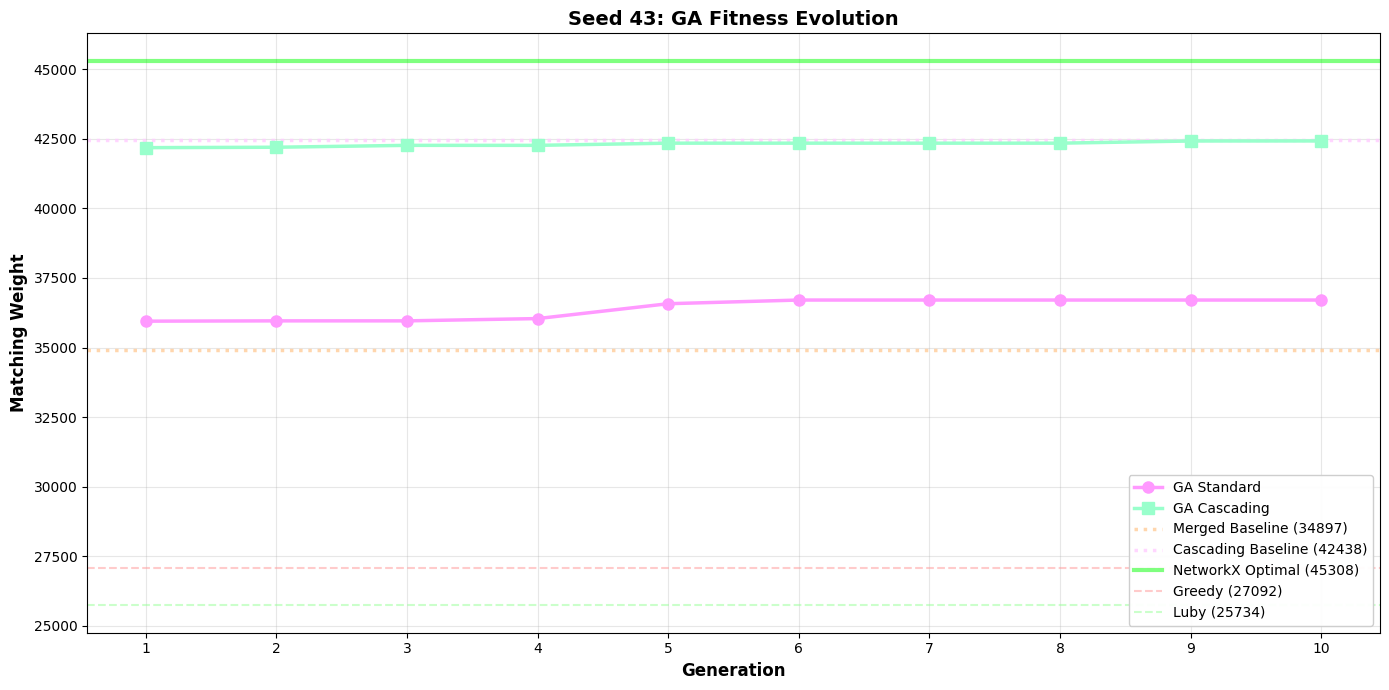

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

gens = list(range(1, len(fitness_history_standard) + 1))

# Plot both GA approaches
ax.plot(gens, fitness_history_standard, 'o-', linewidth=2.5, markersize=8, label='GA Standard', color='#FF99FF', zorder=5)
ax.plot(gens, fitness_history_cascading, 's-', linewidth=2.5, markersize=8, label='GA Cascading', color='#99FFCC', zorder=5)

# Add baseline lines
ax.axhline(y=baseline, color='#FFCC99', linestyle=':', linewidth=2.5, alpha=0.8, label=f'Merged Baseline ({baseline:.0f})')
ax.axhline(y=baseline_cascading, color='#FFCCFF', linestyle=':', linewidth=2.5, alpha=0.8, label=f'Cascading Baseline ({baseline_cascading:.0f})')
ax.axhline(y=optimal, color='#00FF00', linestyle='-', linewidth=3, alpha=0.5, label=f'NetworkX Optimal ({optimal:.0f})')

# Add algorithm baselines
ax.axhline(y=greedy_weight, color='#FF9999', linestyle='--', linewidth=1.5, alpha=0.5, label=f'Greedy ({greedy_weight:.0f})')
ax.axhline(y=luby_weight, color='#99FF99', linestyle='--', linewidth=1.5, alpha=0.5, label=f'Luby ({luby_weight:.0f})')

ax.set_xlabel('Generation', fontsize=12, fontweight='bold')
ax.set_ylabel('Matching Weight', fontsize=12, fontweight='bold')
ax.set_title(f'Seed {seed}: GA Fitness Evolution', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='lower right', framealpha=0.95)
ax.set_xticks(gens)

plt.tight_layout()
plt.show()

## 8. Head-to-Head: Standard vs Cascading

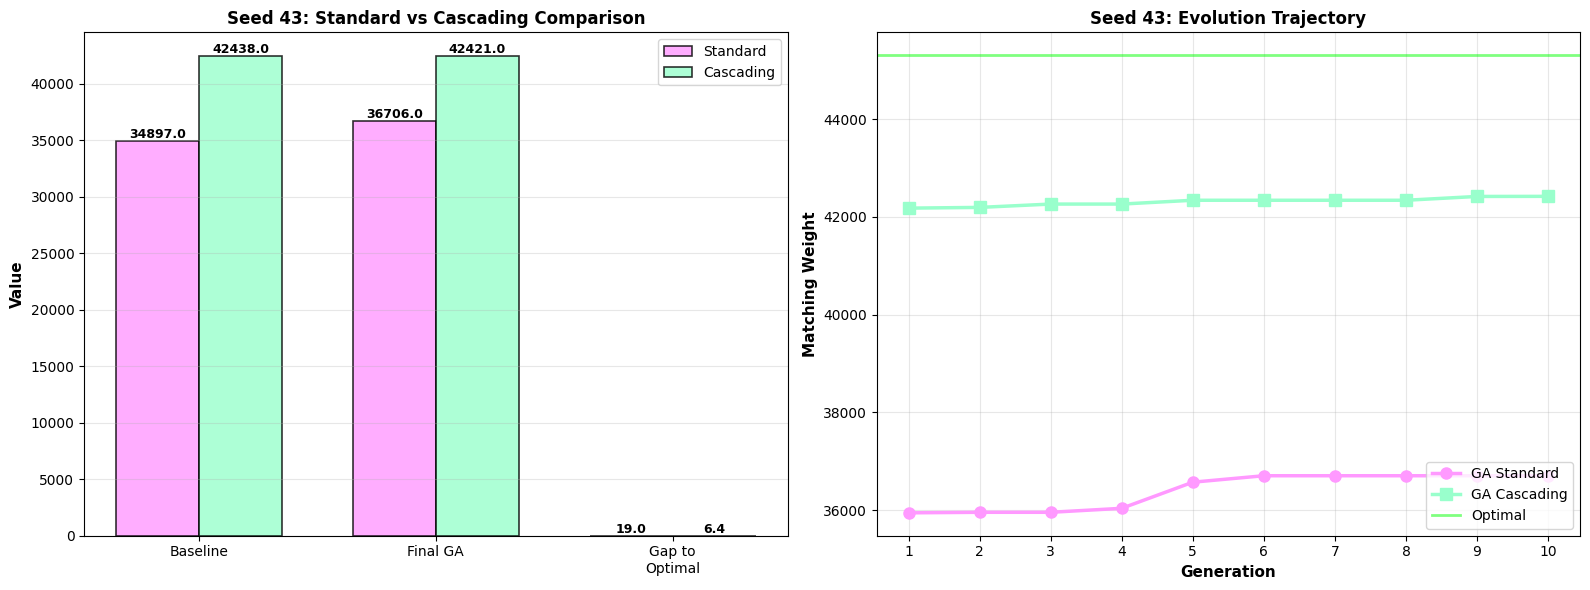

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Absolute fitness comparison
metrics = ['Baseline', 'Final GA', 'Gap to\nOptimal']
standard_vals = [baseline, best_standard, ga_gap]
cascading_vals = [baseline_cascading, best_cascading, cascading_gap]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, standard_vals, width, label='Standard', color='#FF99FF', alpha=0.8, edgecolor='black', linewidth=1.2)
bars2 = ax1.bar(x + width/2, cascading_vals, width, label='Cascading', color='#99FFCC', alpha=0.8, edgecolor='black', linewidth=1.2)

ax1.set_ylabel('Value', fontweight='bold', fontsize=11)
ax1.set_title(f'Seed {seed}: Standard vs Cascading Comparison', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

# Right: Fitness history overlay
gens = list(range(1, len(fitness_history_standard) + 1))
ax2.plot(gens, fitness_history_standard, 'o-', linewidth=2.5, markersize=8, label='GA Standard', color='#FF99FF', zorder=5)
ax2.plot(gens, fitness_history_cascading, 's-', linewidth=2.5, markersize=8, label='GA Cascading', color='#99FFCC', zorder=5)
ax2.axhline(y=optimal, color='#00FF00', linestyle='-', linewidth=2, alpha=0.5, label='Optimal')
ax2.set_xlabel('Generation', fontsize=11, fontweight='bold')
ax2.set_ylabel('Matching Weight', fontsize=11, fontweight='bold')
ax2.set_title(f'Seed {seed}: Evolution Trajectory', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10, loc='lower right')
ax2.set_xticks(gens)

plt.tight_layout()
plt.show()

## 9. Final Summary

In [9]:
print("\n" + "="*80)
print("SUMMARY STATISTICS - SEED 43")
print("="*80)
print()
print("Best Results:")
print(f"  GA Cascading: {best_cascading:>10.0f} (Recommended ✓)")
print(f"  GA Standard:  {best_standard:>10.0f}")
print(f"  Advantage:    {(best_cascading - best_standard):>10.0f} ({(best_cascading / best_standard - 1) * 100:>6.2f}% better)")
print()
print("Gap to Optimal:")
print(f"  GA Cascading: {cascading_gap:>6.2f}%")
print(f"  GA Standard:  {ga_gap:>6.2f}%")
print(f"  Improvement from Cascading: {ga_gap - cascading_gap:>6.2f}% closer to optimal")
print()
print("Improvement over Baseline:")
print(f"  GA Cascading: {improvement_cascading:>6.2f}% (from {baseline_cascading:.0f})")
print(f"  GA Standard:  {improvement_standard:>6.2f}% (from {baseline:.0f})")
print()
print("GA Evolution:")
std_improvement = fitness_history_standard[-1] - fitness_history_standard[0]
casc_improvement = fitness_history_cascading[-1] - fitness_history_cascading[0]
print(f"  Standard: {fitness_history_standard[0]:.0f} → {fitness_history_standard[-1]:.0f} (change: {std_improvement:+.0f})")
print(f"  Cascading: {fitness_history_cascading[0]:.0f} → {fitness_history_cascading[-1]:.0f} (change: {casc_improvement:+.0f})")
print()
print("Algorithm Performance:")
print(f"  Greedy:   {greedy_weight:>10.0f} ({(greedy_weight / optimal * 100):.1f}% of optimal)")
print(f"  Itai:     {itai_weight:>10.0f} ({(itai_weight / optimal * 100):.1f}% of optimal)")
print(f"  Luby:     {luby_weight:>10.0f} ({(luby_weight / optimal * 100):.1f}% of optimal)")
print(f"  Merged:   {baseline:>10.0f} ({(baseline / optimal * 100):.1f}% of optimal)")
print()
print("="*80)


SUMMARY STATISTICS - SEED 43

Best Results:
  GA Cascading:      42421 (Recommended ✓)
  GA Standard:       36706
  Advantage:          5715 ( 15.57% better)

Gap to Optimal:
  GA Cascading:   6.37%
  GA Standard:   18.99%
  Improvement from Cascading:  12.61% closer to optimal

Improvement over Baseline:
  GA Cascading: -13.51% (from 42438)
  GA Standard:    5.18% (from 34897)

GA Evolution:
  Standard: 35947 → 36706 (change: +759)
  Cascading: 42180 → 42421 (change: +241)

Algorithm Performance:
  Greedy:        27092 (59.8% of optimal)
  Itai:          20143 (44.5% of optimal)
  Luby:          25734 (56.8% of optimal)
  Merged:        34897 (77.0% of optimal)

